In [14]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import joblib

In [15]:
df = pd.read_csv("C:/Users/joshd/Documents/ML Project Sem-7/client_wise_sales_2024.csv")

In [16]:
print(df.columns.tolist())

['Customer_Name', 'Sales_Amount', ' Percentage_of_sales ', 'Location', 'Type_of_customer']


In [17]:
X = df[['Sales_Amount']]

In [18]:
# Try 3 clusters: High, Medium, Low customers
kmeans = KMeans(n_clusters=3, random_state=42)
df['Segment'] = kmeans.fit_predict(X)

c:\Users\Admin\anaconda3\envs\dppl_project\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


In [19]:
# Label segments manually (based on cluster centers)
cluster_centers = kmeans.cluster_centers_.flatten()
sorted_indices = cluster_centers.argsort()

segment_labels = {}
segment_labels[sorted_indices[0]] = 'Low Value'
segment_labels[sorted_indices[1]] = 'Medium Value'
segment_labels[sorted_indices[2]] = 'High Value'

df['Segment_Label'] = df['Segment'].map(segment_labels)

In [20]:
df['Segment_Label'] = df['Segment'].map(segment_labels)

print("\nCustomer Segmentation Result:")
print(df[['Customer_Name', 'Sales_Amount', 'Segment_Label']])


Customer Segmentation Result:
                                         Customer_Name  Sales_Amount  \
0                                       1NESS (Mumbai)      35000.00   
1    A K INFRADEAL PRIVATE LIMITED (Maosaji Kajukat...     133000.00   
2      A.P. IMPEX (Bareja) KIMIA GOLD DATES (24 CARAT)     598000.00   
3                                    AALEEJAH OVERSEAS    1471627.12   
4    AALIYA TRADERS (TAB PACK) (Hotel Sri Sakthi Sw...      13000.00   
..                                                 ...           ...   
582  Western Plastech Pvt Ltd (Hareshbhai EX SUPEVI...     363485.59   
583                      What the Foodies (Nava Vadaj)      14400.00   
584                     YADGAR PROVISON STORE (GODHRA)      77822.03   
585     YASH TRADERS (New Janta Sweet (Jodhpur) Lassi)      48150.00   
586                              ZAMCO FOODS (Zam Zam)    2246962.71   

    Segment_Label  
0       Low Value  
1       Low Value  
2       Low Value  
3       Low Value  
4   

) missing from font(s) DejaVu Sans.pykernel_7828\4257631043.py:7: UserWarning: Glyph 13 (
  plt.tight_layout()
) missing from font(s) DejaVu Sans.project\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 13 (
  fig.canvas.print_figure(bytes_io, **kw)


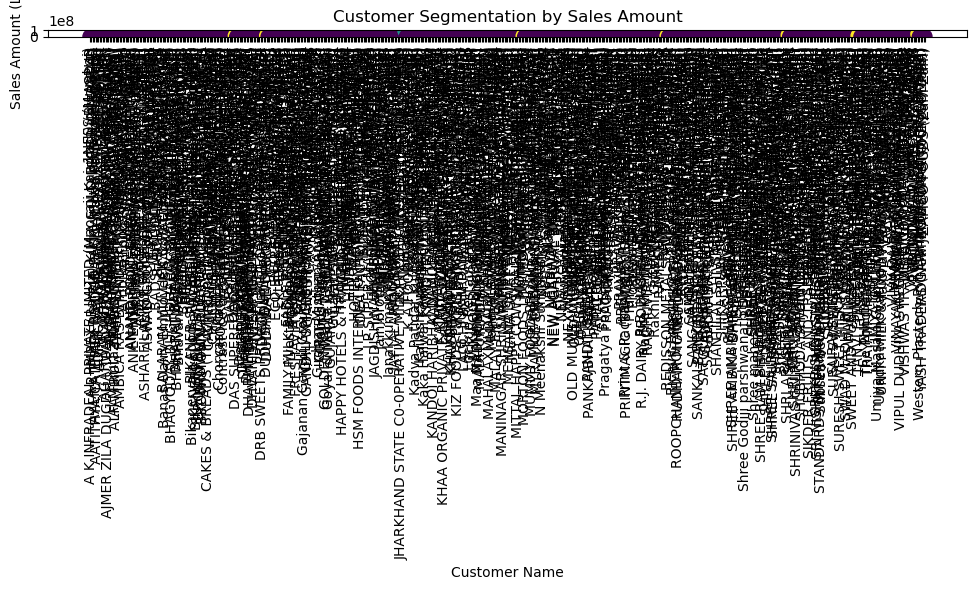

In [21]:
plt.figure(figsize=(10, 6))
plt.scatter(df['Customer_Name'], df['Sales_Amount'], c=df['Segment'], cmap='viridis', s=100)
plt.xticks(rotation=90)
plt.title("Customer Segmentation by Sales Amount")
plt.xlabel("Customer Name")
plt.ylabel("Sales Amount (Lakhs)")
plt.tight_layout()
plt.show()

In [22]:
df.to_csv("client_sales_with_segments_2024.csv", index=False)

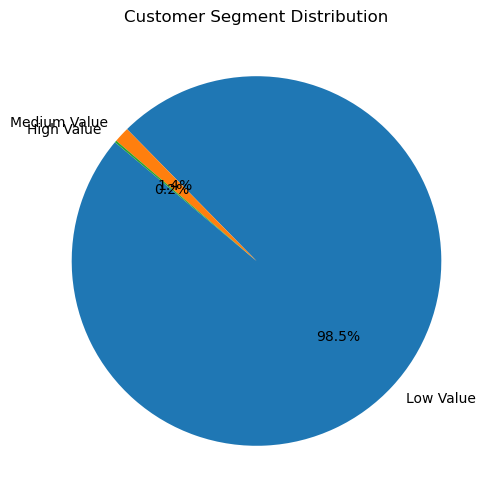

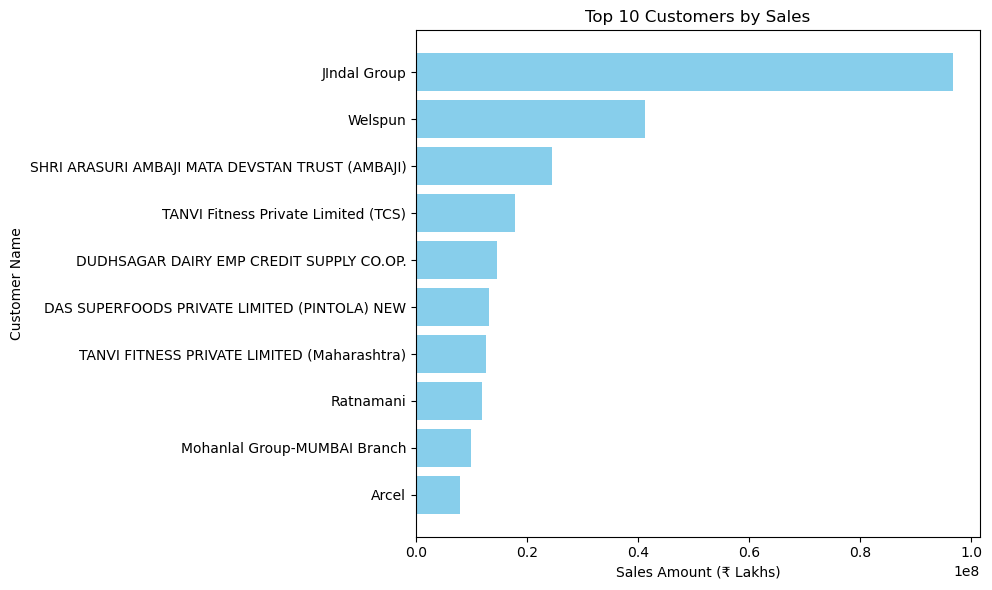

In [23]:
df = pd.read_csv("C:/Users/joshd/Documents/ML Project Sem-7/client_sales_with_segments_2024.csv")

segment_counts = df['Segment_Label'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(segment_counts, labels=segment_counts.index, autopct='%1.1f%%', startangle=140)
plt.title("Customer Segment Distribution")
plt.show()

top_customers = df.sort_values(by='Sales_Amount', ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_customers['Customer_Name'], top_customers['Sales_Amount'], color='skyblue')
plt.xlabel("Sales Amount (₹ Lakhs)")
plt.ylabel("Customer Name")
plt.title("Top 10 Customers by Sales")
plt.gca().invert_yaxis()  # To show the highest at the top
plt.tight_layout()
plt.show()